##EDA Firstcry 


In [19]:
import json

# Read the JSON file
with open('marketplace/firstcry.json', 'r') as file:
    data = json.load(file)

# Display the data
print(data)

[{'title': ['Babyhug Pro Bubble Care Premium Pant Style Diaper Medium (M) Size - 54 Pieces - New & Improved Superior Fit', 'MamyPoko Extra Absorb Pant Style Diaper Medium Size- 148 Pieces', 'MamyPoko Extra Absorb Pants Style Diapers Medium- 74 Pieces', 'Babyhug Advanced Pant Style Diapers Medium (M) Size - 76 Pieces, Honeycomb Technology, Cottony Soft Diaper with 3D Leak Guard, Latex & Alcohol Free, Anti-rash & Gentle', "Huggies Complete Comfort Wonder Pants, India's Fastest Absorbing Diaper | M Size, 152 Diapers", 'BabyhugÂ\xa0Pro Bubble Care Premium Pant Style Diaper Small (S) Size - 70 Pieces - New & Improved Superior Fit', 'Pampers Premium Care Pants, Medium size baby diapers (M), 108 Count, Softest ever Pampers pants', "Huggies Complete Comfort Wonder Pants India's Fastest Absorbing Diaper Medium Size -  228 Diapers", 'MamyPoko Pants All Night Absorb Small - 90 pieces', 'Pampers Premium Care Pants, Medium size baby diapers (M), 54 Count, Softest ever Pampers pants', 'MamyPoko Pant

#Convert file json to csv, more proper table

In [20]:
import json
import csv

# Load the JSON data from the file
with open("marketplace/firstcry.json", "r", encoding="utf-8") as json_file:
    data = json.load(json_file)

# Open a CSV file for writing the transformed data
with open("output.csv", "w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    
    # Write header row
    writer.writerow(["Title", "Product Price", "Original Price", "Club Price", "URL"])
    
    # Process each JSON object in the list
    for idx, obj in enumerate(data):
        titles = obj.get("title", [])
        product_prices = obj.get("product_price", [])
        original_prices = obj.get("original_price", [])
        club_prices = obj.get("club_price", [])
        url = obj.get("url", "")
        
        # Determine the minimum length to avoid index errors
        min_len = min(len(titles), len(product_prices), len(original_prices), len(club_prices))
        if not (len(titles) == len(product_prices) == len(original_prices) == len(club_prices)):
            print(f"Warning: Data mismatch in entry {idx+1}. Only processing first {min_len} items.")
        
        # Write each product's details using zip
        for title, prod_price, orig_price, club_price in zip(titles, product_prices, original_prices, club_prices):
            writer.writerow([title, prod_price, orig_price, club_price, url])

print("CSV file 'output.csv' has been created successfully.")


CSV file 'output.csv' has been created successfully.


In [21]:

import pandas as pd
df = pd.read_csv('output_firstcry.csv')
df.head(10)

,Title,Product Price,Original Price,Club Price,URL
0,Babyhug Pro Bubble Care Premium Pant Style Dia...,620.78,1395,599.85,https://www.firstcry.com/baby-diapers/1/27?sca...
1,MamyPoko Extra Absorb Pant Style Diaper Medium...,1435.95,2599,1383.97,https://www.firstcry.com/baby-diapers/1/27?sca...
2,MamyPoko Extra Absorb Pants Style Diapers Medi...,809.18,1399,781.20,https://www.firstcry.com/baby-diapers/1/27?sca...
3,Babyhug Advanced Pant Style Diapers Medium (M)...,604.03,1299,584.55,https://www.firstcry.com/baby-diapers/1/27?sca...
4,"Huggies Complete Comfort Wonder Pants, India's...",1200.77,2799,1144.79,https://www.firstcry.com/baby-diapers/1/27?sca...
5,Babyhug Pro Bubble Care Premium Pant Style Dia...,648.68,1395,627.75,https://www.firstcry.com/baby-diapers/1/27?sca...
6,"Pampers Premium Care Pants, Medium size baby d...",1561.36,2998,1501.40,https://www.firstcry.com/baby-diapers/1/27?sca...
7,Huggies Complete Comfort Wonder Pants India's ...,1737.61,3099,1675.63,https://www.firstcry.com/baby-diapers/1/27?sca...
8,MamyPoko Pants All Night Absorb Small - 90 pieces,535.08,899,517.10,https://www.firstcry.com/baby-diapers/1/27?sca...
9,"Pampers Premium Care Pants, Medium size baby d...",806.61,1499,776.63,https://www.firstcry.com/baby-diapers/1/27?sca...


In [22]:
df.duplicated(subset=['Title'], keep='first').sum()


np.int64(39)

In [23]:

df.drop_duplicates(subset=['Title'], keep='first', inplace=True)
df.duplicated(subset=['Title'], keep='first').sum()

np.int64(0)

In [24]:
#save the cleaned DataFrame to a new CSV file
#df.to_csv('output_firstcry_cleaned.csv', index=False)

In [25]:

df['Title'] = df['Title'].apply(lambda x: ' '.join(x.split()[:3]))
df.head(10)

,Title,Product Price,Original Price,Club Price,URL
0,Babyhug Pro Bubble,620.78,1395,599.85,https://www.firstcry.com/baby-diapers/1/27?sca...
1,MamyPoko Extra Absorb,1435.95,2599,1383.97,https://www.firstcry.com/baby-diapers/1/27?sca...
2,MamyPoko Extra Absorb,809.18,1399,781.20,https://www.firstcry.com/baby-diapers/1/27?sca...
3,Babyhug Advanced Pant,604.03,1299,584.55,https://www.firstcry.com/baby-diapers/1/27?sca...
4,Huggies Complete Comfort,1200.77,2799,1144.79,https://www.firstcry.com/baby-diapers/1/27?sca...
5,Babyhug Pro Bubble,648.68,1395,627.75,https://www.firstcry.com/baby-diapers/1/27?sca...
6,Pampers Premium Care,1561.36,2998,1501.40,https://www.firstcry.com/baby-diapers/1/27?sca...
7,Huggies Complete Comfort,1737.61,3099,1675.63,https://www.firstcry.com/baby-diapers/1/27?sca...
8,MamyPoko Pants All,535.08,899,517.10,https://www.firstcry.com/baby-diapers/1/27?sca...
9,Pampers Premium Care,806.61,1499,776.63,https://www.firstcry.com/baby-diapers/1/27?sca...


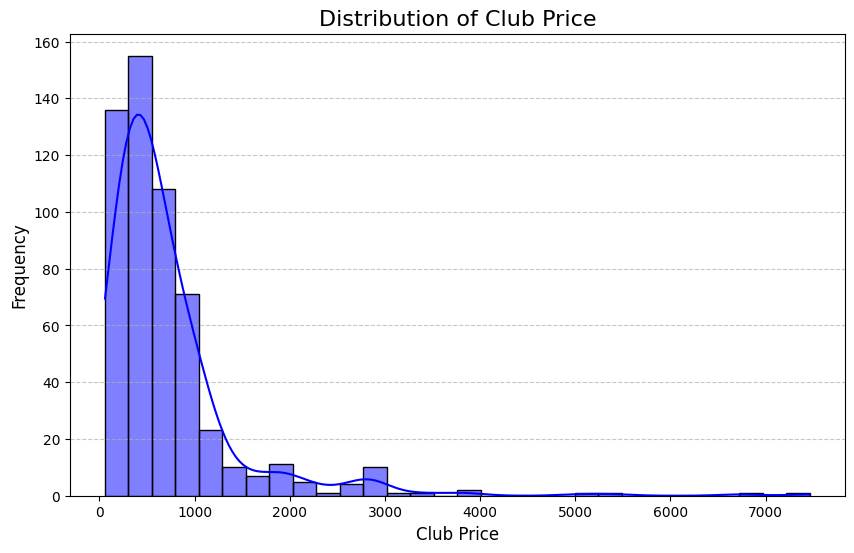

In [26]:
import seaborn as sns

import matplotlib.pyplot as plt
# Analyze the distribution of 'Club Price' in the DataFrame
plt.figure(figsize=(10, 6))
sns.histplot(df['Club Price'], kde=True, bins=30, color='blue')
plt.title('Distribution of Club Price', fontsize=16)
plt.xlabel('Club Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

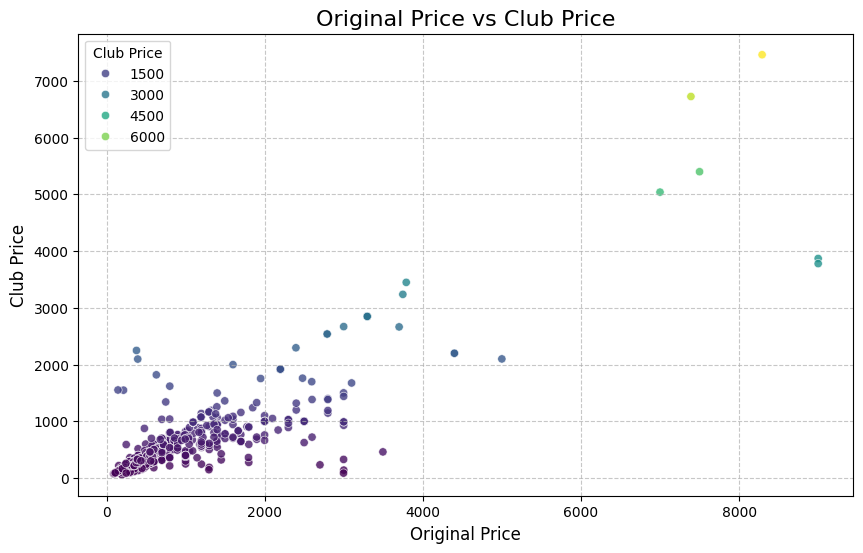

In [27]:
# Analyze the relationship between 'Original Price' and 'Club Price'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Original Price', y='Club Price', hue='Club Price', palette='viridis', alpha=0.8)
plt.title('Original Price vs Club Price', fontsize=16)
plt.xlabel('Original Price', fontsize=12)
plt.ylabel('Club Price', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

<Figure size 1200x600 with 0 Axes>

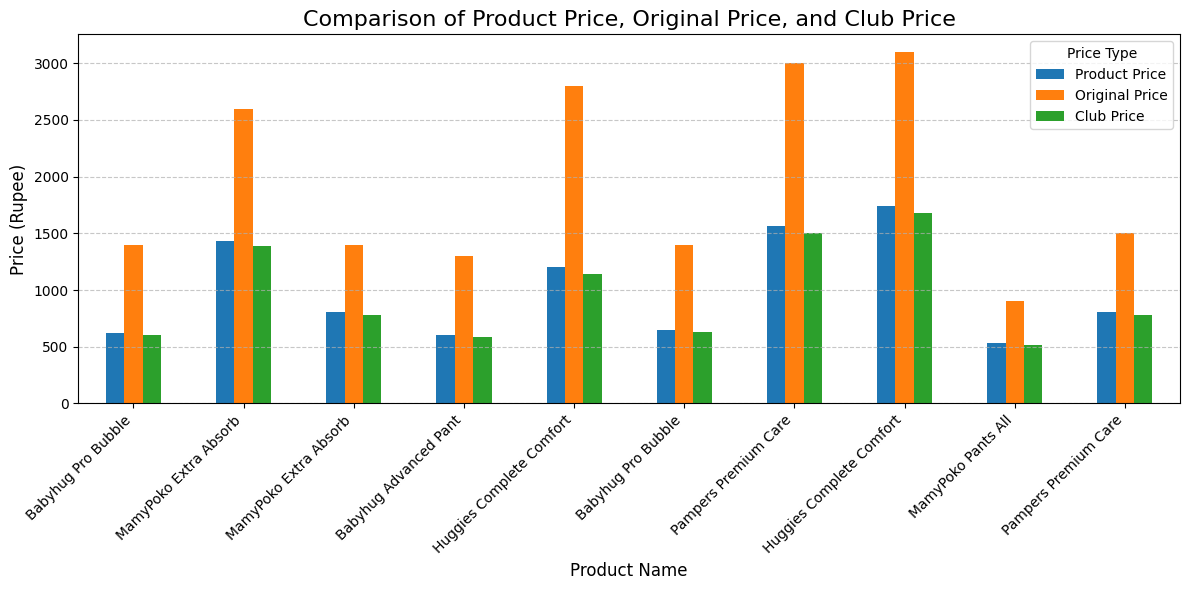

In [28]:
# Compare Product Price, Original Price, and Club Price
plt.figure(figsize=(12, 6))
df[['Product Price', 'Original Price', 'Club Price']].head(10).plot(kind='bar', figsize=(12, 6), legend=True)
plt.title('Comparison of Product Price, Original Price, and Club Price', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Price (Rupee)', fontsize=12)
plt.xticks(ticks=range(10), labels=df['Title'].head(10), rotation=45, ha='right', fontsize=10)
plt.legend(title='Price Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
#calculate total dicount
df['Total Discount Club'] = df['Original Price'] - df['Club Price']
df.head(10)

,Title,Product Price,Original Price,Club Price,URL,Total Discount Club
0,Babyhug Pro Bubble,620.78,1395,599.85,https://www.firstcry.com/baby-diapers/1/27?sca...,795.15
1,MamyPoko Extra Absorb,1435.95,2599,1383.97,https://www.firstcry.com/baby-diapers/1/27?sca...,1215.03
2,MamyPoko Extra Absorb,809.18,1399,781.20,https://www.firstcry.com/baby-diapers/1/27?sca...,617.80
3,Babyhug Advanced Pant,604.03,1299,584.55,https://www.firstcry.com/baby-diapers/1/27?sca...,714.45
4,Huggies Complete Comfort,1200.77,2799,1144.79,https://www.firstcry.com/baby-diapers/1/27?sca...,1654.21
5,Babyhug Pro Bubble,648.68,1395,627.75,https://www.firstcry.com/baby-diapers/1/27?sca...,767.25
6,Pampers Premium Care,1561.36,2998,1501.40,https://www.firstcry.com/baby-diapers/1/27?sca...,1496.60
7,Huggies Complete Comfort,1737.61,3099,1675.63,https://www.firstcry.com/baby-diapers/1/27?sca...,1423.37
8,MamyPoko Pants All,535.08,899,517.10,https://www.firstcry.com/baby-diapers/1/27?sca...,381.90
9,Pampers Premium Care,806.61,1499,776.63,https://www.firstcry.com/baby-diapers/1/27?sca...,722.37


In [30]:
df['Total Discount normal'] = df['Original Price'] - df['Product Price']
df.head(10)

,Title,Product Price,Original Price,Club Price,URL,Total Discount Club,Total Discount normal
0,Babyhug Pro Bubble,620.78,1395,599.85,https://www.firstcry.com/baby-diapers/1/27?sca...,795.15,774.22
1,MamyPoko Extra Absorb,1435.95,2599,1383.97,https://www.firstcry.com/baby-diapers/1/27?sca...,1215.03,1163.05
2,MamyPoko Extra Absorb,809.18,1399,781.20,https://www.firstcry.com/baby-diapers/1/27?sca...,617.80,589.82
3,Babyhug Advanced Pant,604.03,1299,584.55,https://www.firstcry.com/baby-diapers/1/27?sca...,714.45,694.97
4,Huggies Complete Comfort,1200.77,2799,1144.79,https://www.firstcry.com/baby-diapers/1/27?sca...,1654.21,1598.23
5,Babyhug Pro Bubble,648.68,1395,627.75,https://www.firstcry.com/baby-diapers/1/27?sca...,767.25,746.32
6,Pampers Premium Care,1561.36,2998,1501.40,https://www.firstcry.com/baby-diapers/1/27?sca...,1496.60,1436.64
7,Huggies Complete Comfort,1737.61,3099,1675.63,https://www.firstcry.com/baby-diapers/1/27?sca...,1423.37,1361.39
8,MamyPoko Pants All,535.08,899,517.10,https://www.firstcry.com/baby-diapers/1/27?sca...,381.90,363.92
9,Pampers Premium Care,806.61,1499,776.63,https://www.firstcry.com/baby-diapers/1/27?sca...,722.37,692.39


In [31]:
# Calculate percentage discount for Club and Normal
df['Total Discount Club (%)'] = (df['Total Discount Club'] / df['Original Price']) * 100
df['Total Discount normal (%)'] = (df['Total Discount normal'] / df['Original Price']) * 100

# Display the updated DataFrame
df.head(10)

,Title,Product Price,Original Price,Club Price,URL,Total Discount Club,Total Discount normal,Total Discount Club (%),Total Discount normal (%)
0,Babyhug Pro Bubble,620.78,1395,599.85,https://www.firstcry.com/baby-diapers/1/27?sca...,795.15,774.22,57.000000,55.499642
1,MamyPoko Extra Absorb,1435.95,2599,1383.97,https://www.firstcry.com/baby-diapers/1/27?sca...,1215.03,1163.05,46.749904,44.749904
2,MamyPoko Extra Absorb,809.18,1399,781.20,https://www.firstcry.com/baby-diapers/1/27?sca...,617.80,589.82,44.160114,42.160114
3,Babyhug Advanced Pant,604.03,1299,584.55,https://www.firstcry.com/baby-diapers/1/27?sca...,714.45,694.97,55.000000,53.500385
4,Huggies Complete Comfort,1200.77,2799,1144.79,https://www.firstcry.com/baby-diapers/1/27?sca...,1654.21,1598.23,59.100036,57.100036
5,Babyhug Pro Bubble,648.68,1395,627.75,https://www.firstcry.com/baby-diapers/1/27?sca...,767.25,746.32,55.000000,53.499642
6,Pampers Premium Care,1561.36,2998,1501.40,https://www.firstcry.com/baby-diapers/1/27?sca...,1496.60,1436.64,49.919947,47.919947
7,Huggies Complete Comfort,1737.61,3099,1675.63,https://www.firstcry.com/baby-diapers/1/27?sca...,1423.37,1361.39,45.929977,43.929977
8,MamyPoko Pants All,535.08,899,517.10,https://www.firstcry.com/baby-diapers/1/27?sca...,381.90,363.92,42.480534,40.480534
9,Pampers Premium Care,806.61,1499,776.63,https://www.firstcry.com/baby-diapers/1/27?sca...,722.37,692.39,48.190127,46.190127


<Figure size 1200x600 with 0 Axes>

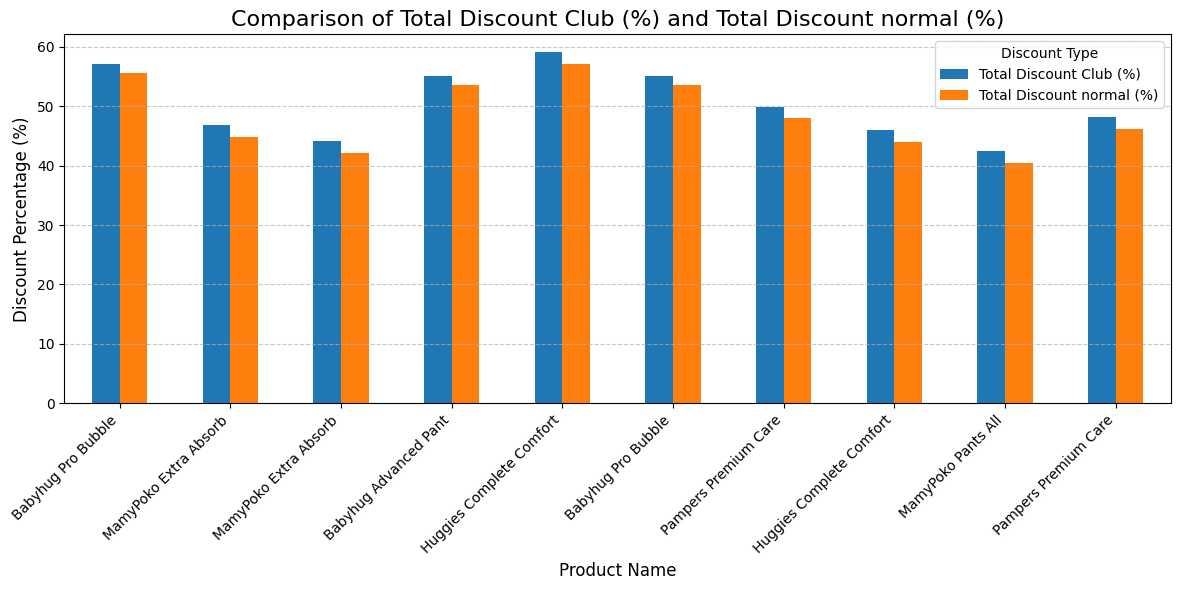

In [58]:
#make graph compare persentage discount
plt.figure(figsize=(12, 6))
df[['Total Discount Club (%)', 'Total Discount normal (%)']].head(10).plot(kind='bar', figsize=(12, 6), legend=True)
plt.title('Comparison of Total Discount Club (%) and Total Discount normal (%)', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Discount Percentage (%)', fontsize=12)
plt.xticks(ticks=range(10), labels=df['Title'].head(10), rotation=45, ha='right', fontsize=10)
plt.legend(title='Discount Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  
plt.show()

<Figure size 1200x600 with 0 Axes>

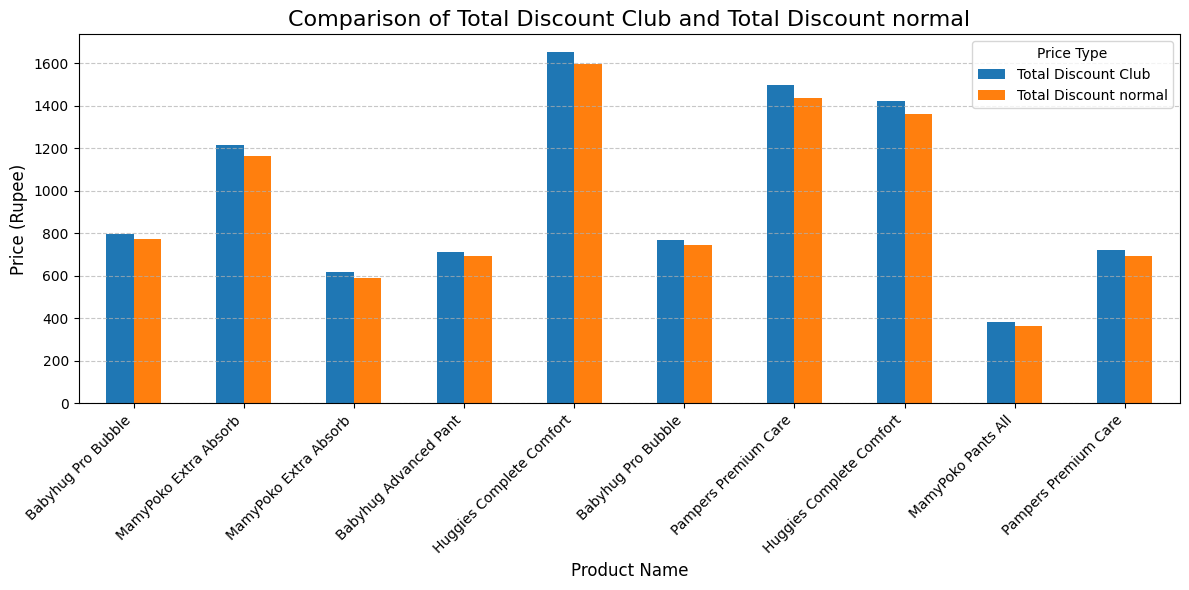

In [32]:
#make graph for total discount
plt.figure(figsize=(12, 6))
df[['Total Discount Club', 'Total Discount normal']].head(10).plot(kind='bar', figsize=(12, 6), legend=True)
plt.title('Comparison of Total Discount Club and Total Discount normal', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Price (Rupee)', fontsize=12)
plt.xticks(ticks=range(10), labels=df['Title'].head(10), rotation=45, ha='right', fontsize=10)
plt.legend(title='Price Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Snooplay

In [33]:
import pandas as pd
df_snooplay = pd.read_csv("marketplace/snooplay2.csv")
df_snooplay.head(10)

,title,product_price,original_price,price_w_discount,url
0,Global Play Tent House with Wheels (1-7 Years),832.5,1125.0,749.25,https://snooplay.in/products/global-play-tent-...
1,"Football with Air Pump & Pin - Size 1 Mini, 12...",349.0,599.0,314.10,https://snooplay.in/products/football-with-air...
2,Flexible Swing Seat with Metal Triangle Hook w...,3499.0,6999.0,3149.10,https://snooplay.in/products/flexible-swing-se...
3,Nippon Cricket Set with Bag (1.5-3 Years),155.0,360.0,139.50,https://snooplay.in/products/nippon-cricket-se...
4,Tokri Tricycle with two point safety belts | 3...,1275.0,2499.0,NaN,https://snooplay.in/products/maanit-tricycle-t...
5,Small Bowling Set Box (3-10 Years),399.0,499.0,359.10,https://snooplay.in/products/small-bowling-set...
6,Zoo Little Kid Backpack-Shark,2159.0,2399.0,1943.10,https://snooplay.in/products/zoo-little-kid-ba...
7,KRT 1.6 Toy Car (Pull Back Car) - Assorted Col...,299.0,346.0,NaN,https://snooplay.in/products/krt-creta-toy-car...
8,Wooden Domino Toy - 100 Pieces (3-7 Years),299.0,599.0,269.10,https://snooplay.in/products/wooden-domino-toy...
9,Saina Doll - 3.2 feet (3-7 Years),2699.1,3200.0,2429.19,https://snooplay.in/products/saina-doll-3-2-fe...


In [34]:

#remove  ₹ and change the datatype to int
"""df_snooplay['product_price'] = df_snooplay['product_price'].str.replace('₹', '').str.replace(',', '')
df_snooplay.head(10)"""

"df_snooplay['product_price'] = df_snooplay['product_price'].str.replace('₹', '').str.replace(',', '')\ndf_snooplay.head(10)"

In [35]:
df_snooplay.tail(10)

,title,product_price,original_price,price_w_discount,url
120,Natural Rubber Foam Tool Set For Kids,864.0,1499.0,777.60,https://snooplay.in/products/natural-rubber-fo...
121,Sweet Kitchen Set For Kids Pretend Playset (3-...,571.5,635.0,514.35,https://snooplay.in/products/sweet-kitchen-set...
122,Social Humour Cards Game (18 Years till Grown ...,989.1,1100.0,890.19,https://snooplay.in/products/social-humour-car...
123,Natural Rubber Foam Tool Set For Kids,864.0,1499.0,777.60,https://snooplay.in/products/natural-rubber-fo...
124,Social Humour Cards Game (18 Years till Grown ...,989.1,1100.0,890.19,https://snooplay.in/products/social-humour-car...
125,Foldable Doll House Play Set (3-7 Years),719.1,799.0,647.19,https://snooplay.in/products/foldable-doll-hou...
126,Natural Rubber Foam Tool Set For Kids,864.0,1499.0,777.60,https://snooplay.in/products/natural-rubber-fo...
127,The Game of Life Board Game (9 Years till Grow...,764.1,899.0,NaN,https://snooplay.in/products/the-game-of-life-...
128,The Game of Life Board Game (9 Years till Grow...,764.1,899.0,NaN,https://snooplay.in/products/the-game-of-life-...
129,The Game of Life Board Game (9 Years till Grow...,764.1,899.0,NaN,https://snooplay.in/products/the-game-of-life-...


In [36]:
#check duplicates
df_snooplay.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             130 non-null    object 
 1   product_price     130 non-null    float64
 2   original_price    112 non-null    float64
 3   price_w_discount  101 non-null    float64
 4   url               130 non-null    object 
dtypes: float64(3), object(2)
memory usage: 5.2+ KB


In [37]:
#check duplicate on title
df_snooplay.duplicated(subset=['title'], keep='first').sum()

np.int64(52)

In [38]:
#remove duplicates
df_snooplay.drop_duplicates(subset=['title'], keep='first', inplace=True)

In [39]:
df_snooplay.duplicated(subset=['title'], keep='first').sum()

np.int64(0)

In [40]:
#make title only 3 words
df_snooplay['title'] = df_snooplay['title'].apply(lambda x: ' '.join(x.split()[:3]))

In [41]:
df_snooplay.head(10)

,title,product_price,original_price,price_w_discount,url
0,Global Play Tent,832.5,1125.0,749.25,https://snooplay.in/products/global-play-tent-...
1,Football with Air,349.0,599.0,314.10,https://snooplay.in/products/football-with-air...
2,Flexible Swing Seat,3499.0,6999.0,3149.10,https://snooplay.in/products/flexible-swing-se...
3,Nippon Cricket Set,155.0,360.0,139.50,https://snooplay.in/products/nippon-cricket-se...
4,Tokri Tricycle with,1275.0,2499.0,NaN,https://snooplay.in/products/maanit-tricycle-t...
5,Small Bowling Set,399.0,499.0,359.10,https://snooplay.in/products/small-bowling-set...
6,Zoo Little Kid,2159.0,2399.0,1943.10,https://snooplay.in/products/zoo-little-kid-ba...
7,KRT 1.6 Toy,299.0,346.0,NaN,https://snooplay.in/products/krt-creta-toy-car...
8,Wooden Domino Toy,299.0,599.0,269.10,https://snooplay.in/products/wooden-domino-toy...
9,Saina Doll -,2699.1,3200.0,2429.19,https://snooplay.in/products/saina-doll-3-2-fe...


In [42]:
#if there is Nan then replace it with product price
df_snooplay['product_price'].fillna(df_snooplay['product_price'], inplace=True)

<Figure size 1200x1000 with 0 Axes>

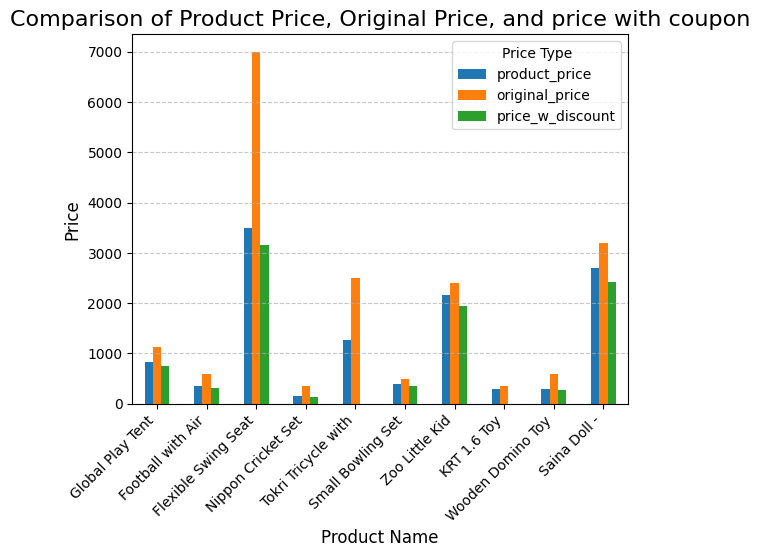

In [51]:
# Ensure the columns are numeric for plotting
df_snooplay[['product_price', 'original_price', 'price_w_discount']] = df_snooplay[['product_price', 'original_price', 'price_w_discount']].apply(pd.to_numeric, errors='coerce')

# Plot the data
plt.figure(figsize=(12, 10))
df_snooplay[['product_price', 'original_price', 'price_w_discount']].head(10).plot(kind='bar', legend=True)
plt.title('Comparison of Product Price, Original Price, and price with coupon', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(ticks=range(10), labels=df_snooplay['title'].head(10), rotation=45, ha='right', fontsize=10) 
plt.legend(title='Price Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [54]:
#calculate total dicount
df_snooplay['Total Discount in product'] = df_snooplay['original_price'] - df_snooplay['product_price']
#make percentage discount
df_snooplay['Total Discount in product (%)'] = round((df_snooplay['Total Discount in product'] / df_snooplay['original_price']) * 100,2)
df_snooplay.head(10)



,title,product_price,original_price,price_w_discount,url,Total Discount,Total Discount in product,Total Discount in product (%)
0,Global Play Tent,832.5,1125.0,749.25,https://snooplay.in/products/global-play-tent-...,292.5,292.5,26.00
1,Football with Air,349.0,599.0,314.10,https://snooplay.in/products/football-with-air...,250.0,250.0,41.74
2,Flexible Swing Seat,3499.0,6999.0,3149.10,https://snooplay.in/products/flexible-swing-se...,3500.0,3500.0,50.01
3,Nippon Cricket Set,155.0,360.0,139.50,https://snooplay.in/products/nippon-cricket-se...,205.0,205.0,56.94
4,Tokri Tricycle with,1275.0,2499.0,NaN,https://snooplay.in/products/maanit-tricycle-t...,1224.0,1224.0,48.98
5,Small Bowling Set,399.0,499.0,359.10,https://snooplay.in/products/small-bowling-set...,100.0,100.0,20.04
6,Zoo Little Kid,2159.0,2399.0,1943.10,https://snooplay.in/products/zoo-little-kid-ba...,240.0,240.0,10.00
7,KRT 1.6 Toy,299.0,346.0,NaN,https://snooplay.in/products/krt-creta-toy-car...,47.0,47.0,13.58
8,Wooden Domino Toy,299.0,599.0,269.10,https://snooplay.in/products/wooden-domino-toy...,300.0,300.0,50.08
9,Saina Doll -,2699.1,3200.0,2429.19,https://snooplay.in/products/saina-doll-3-2-fe...,500.9,500.9,15.65


In [56]:
#calculate total dicount price with coupon
df_snooplay['Total Discount in coupon'] = df_snooplay['original_price'] - df_snooplay['price_w_discount']
#make percentage discount
df_snooplay['Total Discount in coupon (%)'] = round((df_snooplay['Total Discount in coupon'] / df_snooplay['original_price']) * 100,2)
df_snooplay.head(10)

,title,product_price,original_price,price_w_discount,url,Total Discount,Total Discount in product,Total Discount in product (%),Total Discount in coupon,Total Discount in coupon (%)
0,Global Play Tent,832.5,1125.0,749.25,https://snooplay.in/products/global-play-tent-...,292.5,292.5,26.00,375.75,33.40
1,Football with Air,349.0,599.0,314.10,https://snooplay.in/products/football-with-air...,250.0,250.0,41.74,284.90,47.56
2,Flexible Swing Seat,3499.0,6999.0,3149.10,https://snooplay.in/products/flexible-swing-se...,3500.0,3500.0,50.01,3849.90,55.01
3,Nippon Cricket Set,155.0,360.0,139.50,https://snooplay.in/products/nippon-cricket-se...,205.0,205.0,56.94,220.50,61.25
4,Tokri Tricycle with,1275.0,2499.0,NaN,https://snooplay.in/products/maanit-tricycle-t...,1224.0,1224.0,48.98,NaN,NaN
5,Small Bowling Set,399.0,499.0,359.10,https://snooplay.in/products/small-bowling-set...,100.0,100.0,20.04,139.90,28.04
6,Zoo Little Kid,2159.0,2399.0,1943.10,https://snooplay.in/products/zoo-little-kid-ba...,240.0,240.0,10.00,455.90,19.00
7,KRT 1.6 Toy,299.0,346.0,NaN,https://snooplay.in/products/krt-creta-toy-car...,47.0,47.0,13.58,NaN,NaN
8,Wooden Domino Toy,299.0,599.0,269.10,https://snooplay.in/products/wooden-domino-toy...,300.0,300.0,50.08,329.90,55.08
9,Saina Doll -,2699.1,3200.0,2429.19,https://snooplay.in/products/saina-doll-3-2-fe...,500.9,500.9,15.65,770.81,24.09


<Figure size 1200x600 with 0 Axes>

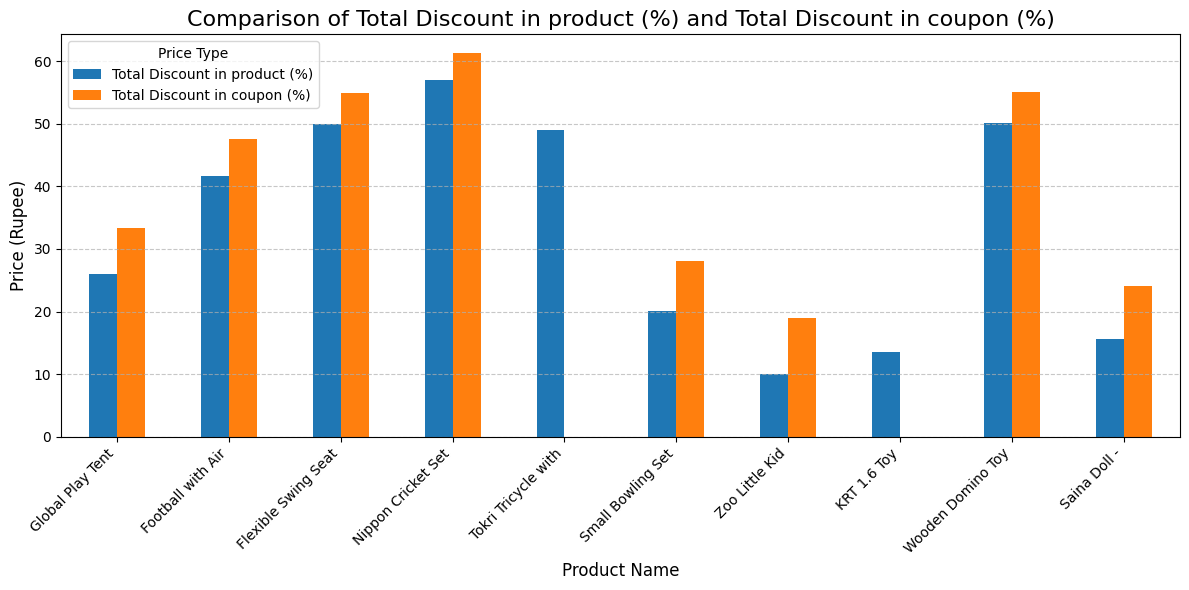

In [57]:
#make graph compare persentage discount
plt.figure(figsize=(12, 6))
df_snooplay[['Total Discount in product (%)', 'Total Discount in coupon (%)']].head(10).plot(kind='bar', figsize=(12, 6), legend=True)
plt.title('Comparison of Total Discount in product (%) and Total Discount in coupon (%)', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Price (Rupee)', fontsize=12)
plt.xticks(ticks=range(10), labels=df_snooplay['title'].head(10), rotation=45, ha='right', fontsize=10)
plt.legend(title='Price Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
"""
import pandas as pd

def convert_price_to_float(price_string):
  
    if not isinstance(price_string, str):
        return None  # or return the original value

    try:
        # Remove currency symbols, commas, and other non-numeric characters
        cleaned_price = ''.join(c for c in price_string if c.isdigit() or c == '.')

        # Convert to float
        return float(cleaned_price)
    except ValueError:
        return None  # or return the original value

df_snooplay = pd.read_csv("marketplace/snooplay.csv")

# Apply the conversion function to the 'product_price' column
# Only apply the function to string values
df_snooplay['product_price'] = df_snooplay['product_price'].apply(lambda x: convert_price_to_float(x) if isinstance(x, str) else x)

df_snooplay.head(10)

"""

'\nimport pandas as pd\n\ndef convert_price_to_float(price_string):\n\n    if not isinstance(price_string, str):\n        return None  # or return the original value\n\n    try:\n        # Remove currency symbols, commas, and other non-numeric characters\n        cleaned_price = \'\'.join(c for c in price_string if c.isdigit() or c == \'.\')\n\n        # Convert to float\n        return float(cleaned_price)\n    except ValueError:\n        return None  # or return the original value\n\ndf_snooplay = pd.read_csv("marketplace/snooplay.csv")\n\n# Apply the conversion function to the \'product_price\' column\n# Only apply the function to string values\ndf_snooplay[\'product_price\'] = df_snooplay[\'product_price\'].apply(lambda x: convert_price_to_float(x) if isinstance(x, str) else x)\n\ndf_snooplay.head(10)\n\n'

In [ ]:
"""
# Apply the conversion function to the 'original_price' column
# Only apply the function to string values
df_snooplay['original_price'] = df_snooplay['original_price'].apply(lambda x: convert_price_to_float(x) if isinstance(x, str) else x)
df_snooplay.head(10)"""

"\n# Apply the conversion function to the 'original_price' column\n# Only apply the function to string values\ndf_snooplay['original_price'] = df_snooplay['original_price'].apply(lambda x: convert_price_to_float(x) if isinstance(x, str) else x)\ndf_snooplay.head(10)"

In [ ]:

"""# Apply the conversion function to the 'price_w_discount' column
# Only apply the function to string values
df_snooplay['price_w_discount'] = df_snooplay['price_w_discount'].apply(lambda x: convert_price_to_float(x) if isinstance(x, str) else x)
df_snooplay.head(10)"""

"# Apply the conversion function to the 'price_w_discount' column\n# Only apply the function to string values\ndf_snooplay['price_w_discount'] = df_snooplay['price_w_discount'].apply(lambda x: convert_price_to_float(x) if isinstance(x, str) else x)\ndf_snooplay.head(10)"

In [ ]:
#save the cleaned DataFrame to a new CSV file
#df_snooplay.to_csv('output_snooplay_cleaned.csv', index=False)
